In [5]:
  import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
data=pd.read_csv("mec_training_dataset_v2.csv")

In [7]:
data.head()

,Object,Time Step,Vehicle_ID,Latitude,Longitude,Speed_kmh,Traffic_Density,Road_Type,Weather,Data_Type,Urgency_Level,MEC_Server_ID,Server_Load_Percent,Latency_ms
0,User_16,1,16,7,1,70.00,0.695,Urban,Rain,Text,5.0,5.0,13.67,28.52
1,User_18,1,18,7,1,45.83,0.125,Highway,Rain,Text,1.0,5.0,13.67,15.25
2,User_20,1,20,7,1,108.65,0.444,Highway,Rain,Video,4.0,5.0,13.67,21.92
3,User_48,1,48,7,1,71.47,0.427,Highway,Rain,Sensor,1.0,5.0,13.67,20.55
4,User_54,1,54,7,1,64.99,0.911,Urban,Clear,Text,2.0,5.0,13.67,26.61


In [8]:
data.shape

(9819, 14)

In [9]:
data.isna().sum()

,0
Object,0
Time Step,0
Vehicle_ID,0
Latitude,0
Longitude,0
Speed_kmh,0
Traffic_Density,0
Road_Type,0
Weather,0
Data_Type,0


In [10]:
data.isna().sum().sum()

np.int64(0)

In [11]:
(data==0).sum()

,0
Object,0
Time Step,0
Vehicle_ID,0
Latitude,931
Longitude,2205
Speed_kmh,0
Traffic_Density,0
Road_Type,0
Weather,0
Data_Type,0


In [12]:
data[(data==0).any(axis=1)]

,Object,Time Step,Vehicle_ID,Latitude,Longitude,Speed_kmh,Traffic_Density,Road_Type,Weather,Data_Type,Urgency_Level,MEC_Server_ID,Server_Load_Percent,Latency_ms
19,User_7,2,7,2,0,79.49,0.528,Urban,Rain,Emergency,3.0,1.0,95.50,31.30
24,User_12,2,12,4,0,63.73,0.264,Highway,Clear,Emergency,5.0,3.0,100.00,17.87
25,User_13,2,13,6,0,87.76,0.333,Rural,Clear,Video,4.0,3.0,100.00,16.63
26,User_14,2,14,0,0,49.69,0.198,Highway,Rain,Sensor,5.0,1.0,95.50,16.46
27,User_15,2,15,4,0,75.00,0.652,Rural,Fog,Text,4.0,3.0,100.00,36.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9803,User_191,50,191,4,0,34.65,0.335,Rural,Fog,Sensor,1.0,5.0,25.67,35.06
9808,User_196,50,196,0,2,77.21,0.630,Rural,Clear,Text,3.0,2.0,69.50,20.77
9813,User_201,50,201,4,0,47.90,0.309,Urban,Fog,Text,4.0,3.0,100.00,32.07
9815,User_203,50,203,0,0,50.30,0.455,Urban,Clear,Video,3.0,1.0,95.50,19.33


In [13]:
data.columns

Index(['Object', 'Time Step', 'Vehicle_ID', 'Latitude', 'Longitude',
       'Speed_kmh', 'Traffic_Density', 'Road_Type', 'Weather', 'Data_Type',
       'Urgency_Level', 'MEC_Server_ID', 'Server_Load_Percent', 'Latency_ms'],
      dtype='object')

In [14]:
data.duplicated().sum()

np.int64(0)

In [15]:
data.describe()

,Time Step,Vehicle_ID,Latitude,Longitude,Speed_kmh,Traffic_Density,Urgency_Level,MEC_Server_ID,Server_Load_Percent,Latency_ms
count,9819.000000,9819.000000,9819.000000,9819.000000,9819.000000,9819.000000,9819.000000,9819.000000,9819.000000,9819.000000
mean,25.951624,106.475201,3.746308,1.528974,60.142308,0.512621,3.214482,3.737448,82.614332,27.464961
std,14.171821,57.736031,2.245818,1.103362,28.500302,0.234112,1.438715,1.889792,26.557205,6.372039
min,1.000000,7.000000,0.000000,0.000000,12.410000,0.012000,1.000000,1.000000,13.670000,12.580000
25%,14.000000,56.000000,2.000000,1.000000,40.820000,0.327000,2.000000,2.000000,69.500000,22.790000
50%,26.000000,106.000000,4.000000,1.000000,55.850000,0.513000,3.000000,4.000000,100.000000,27.230000
75%,38.000000,156.000000,6.000000,3.000000,75.250000,0.695000,4.000000,6.000000,100.000000,31.590000
max,50.000000,206.000000,7.000000,3.000000,140.000000,0.953000,5.000000,6.000000,100.000000,43.160000


In [16]:
data.describe(include='object')

,Object,Road_Type,Weather,Data_Type
count,9819,9819,9819,9819
unique,200,3,3,4
top,User_16,Highway,Clear,Emergency
freq,50,3830,3437,2894


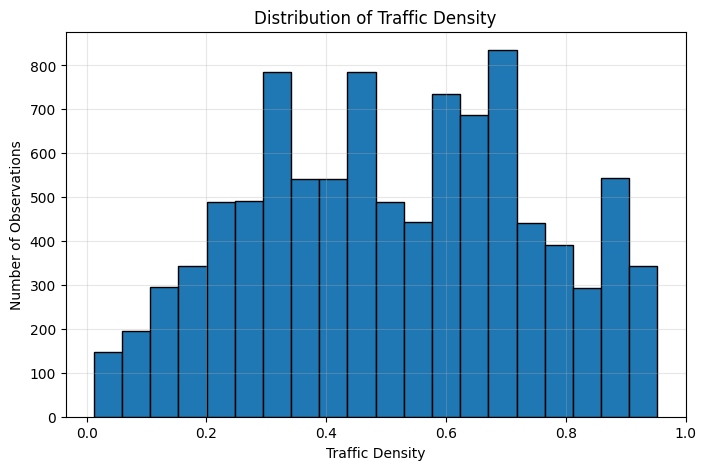

In [17]:
plt.figure(figsize=(8,5))
plt.hist(data["Traffic_Density"], bins=20, edgecolor="black")
plt.title("Distribution of Traffic Density")
plt.xlabel("Traffic Density")
plt.ylabel("Number of Observations")
plt.grid(alpha=0.3)
plt.show()

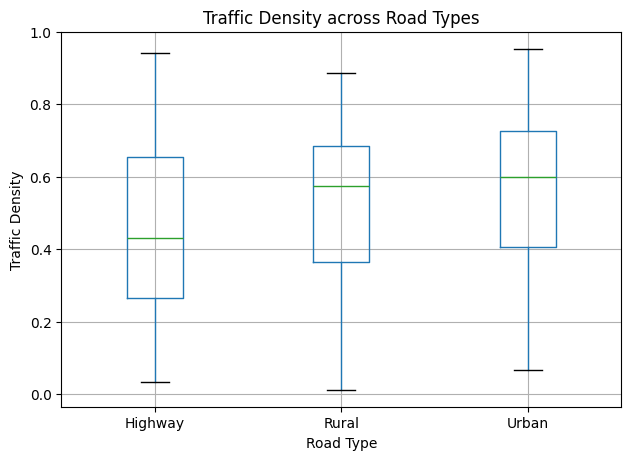

In [18]:
import matplotlib.pyplot as plt

data.boxplot(column="Traffic_Density", by="Road_Type", figsize=(7,5))
plt.title("Traffic Density across Road Types")
plt.suptitle("")
plt.xlabel("Road Type")
plt.ylabel("Traffic Density")
plt.show()

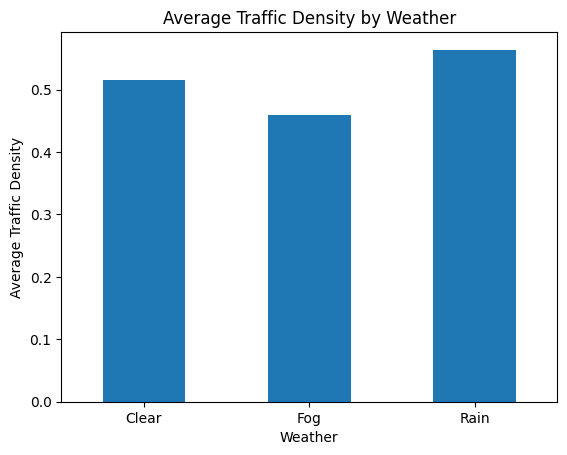

In [19]:
traffic_weather = data.groupby("Weather")["Traffic_Density"].mean()

traffic_weather.plot(kind="bar")
plt.title("Average Traffic Density by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Traffic Density")
plt.xticks(rotation=0)
plt.show()

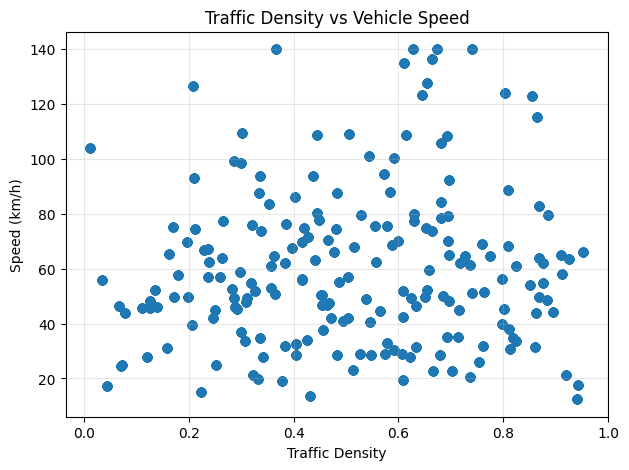

In [20]:
plt.figure(figsize=(7,5))
plt.scatter(data["Traffic_Density"], data["Speed_kmh"], alpha=0.5)
plt.title("Traffic Density vs Vehicle Speed")
plt.xlabel("Traffic Density")
plt.ylabel("Speed (km/h)")
plt.grid(alpha=0.3)
plt.show()

In [21]:
corr = data.corr(numeric_only=True)

corr["Traffic_Density"].sort_values(ascending=False)

,Traffic_Density
Traffic_Density,1.000000
Latency_ms,0.509337
Speed_kmh,0.075350
Vehicle_ID,0.073731
Urgency_Level,0.010547
Time Step,-0.000647
MEC_Server_ID,-0.009520
Longitude,-0.045537
Latitude,-0.066239
Server_Load_Percent,-0.154981


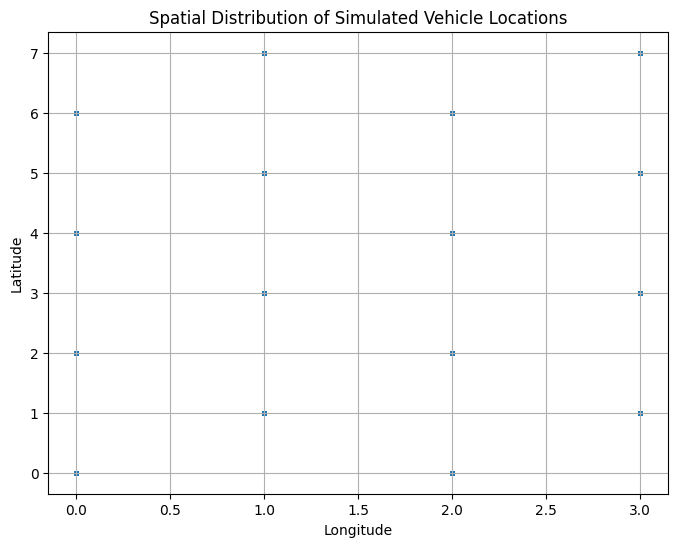

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(data["Longitude"], data["Latitude"], s=5, alpha=0.5)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Simulated Vehicle Locations")
plt.grid(True)

plt.show()

In [23]:
network_features=['Object', 'Time Step', 'Vehicle_ID', 'Latitude', 'Longitude', 'Speed_kmh', 'Traffic_Density', 'Road_Type', 'Weather', 'Data_Type', 'Urgency_Level', 'MEC_Server_ID', 'Server_Load_Percent', 'Latency_ms']

data[network_features].describe()

,Time Step,Vehicle_ID,Latitude,Longitude,Speed_kmh,Traffic_Density,Urgency_Level,MEC_Server_ID,Server_Load_Percent,Latency_ms
count,9819.000000,9819.000000,9819.000000,9819.000000,9819.000000,9819.000000,9819.000000,9819.000000,9819.000000,9819.000000
mean,25.951624,106.475201,3.746308,1.528974,60.142308,0.512621,3.214482,3.737448,82.614332,27.464961
std,14.171821,57.736031,2.245818,1.103362,28.500302,0.234112,1.438715,1.889792,26.557205,6.372039
min,1.000000,7.000000,0.000000,0.000000,12.410000,0.012000,1.000000,1.000000,13.670000,12.580000
25%,14.000000,56.000000,2.000000,1.000000,40.820000,0.327000,2.000000,2.000000,69.500000,22.790000
50%,26.000000,106.000000,4.000000,1.000000,55.850000,0.513000,3.000000,4.000000,100.000000,27.230000
75%,38.000000,156.000000,6.000000,3.000000,75.250000,0.695000,4.000000,6.000000,100.000000,31.590000
max,50.000000,206.000000,7.000000,3.000000,140.000000,0.953000,5.000000,6.000000,100.000000,43.160000


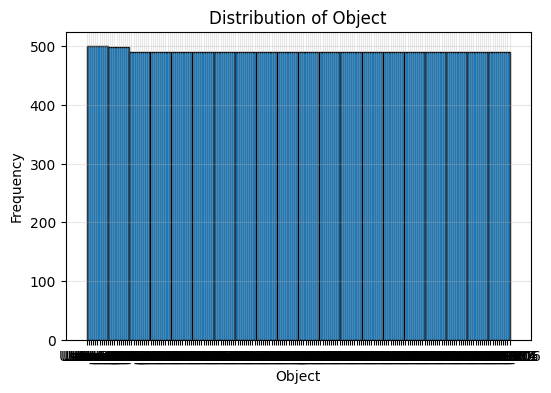

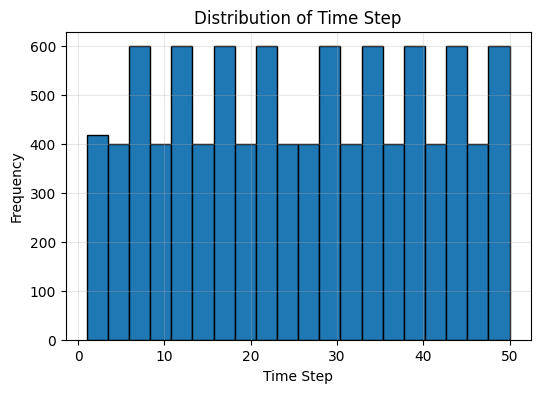

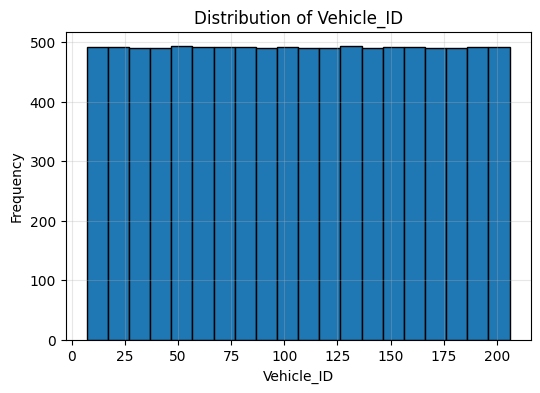

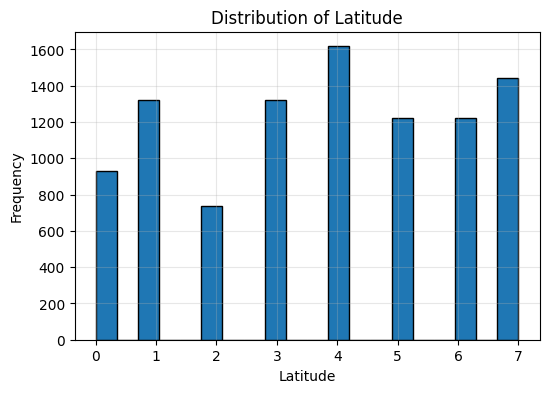

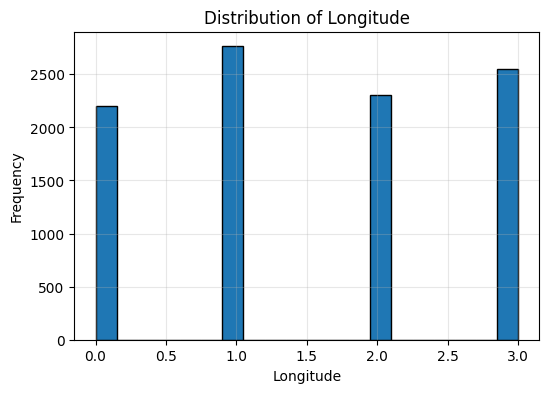

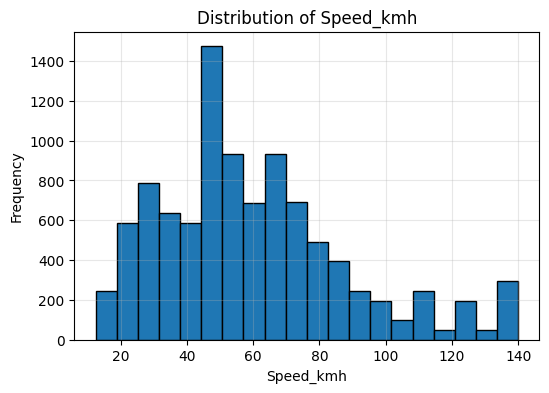

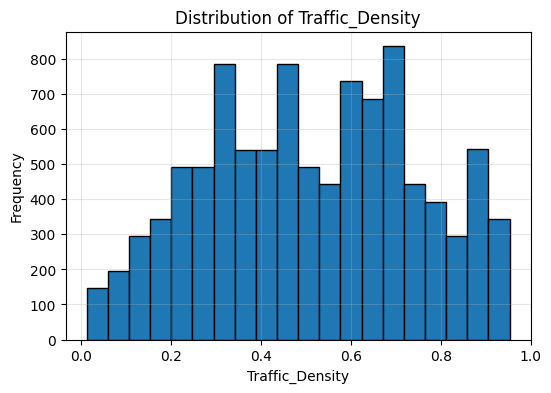

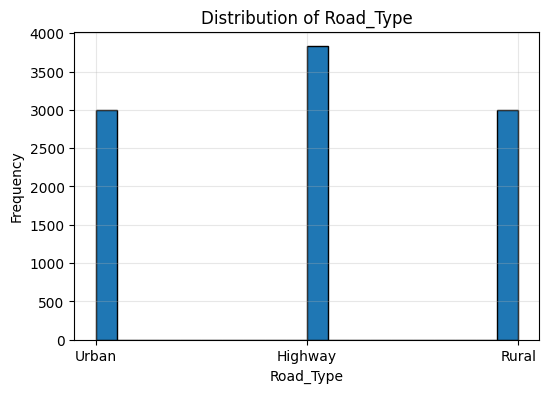

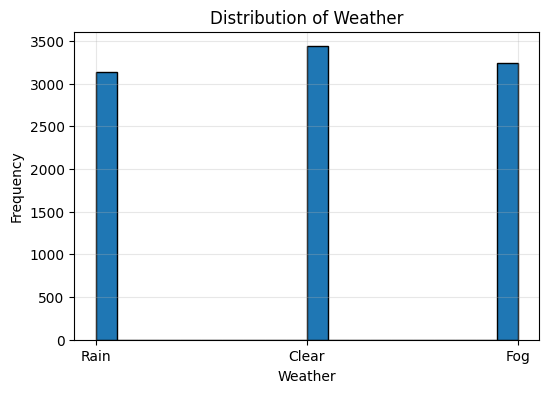

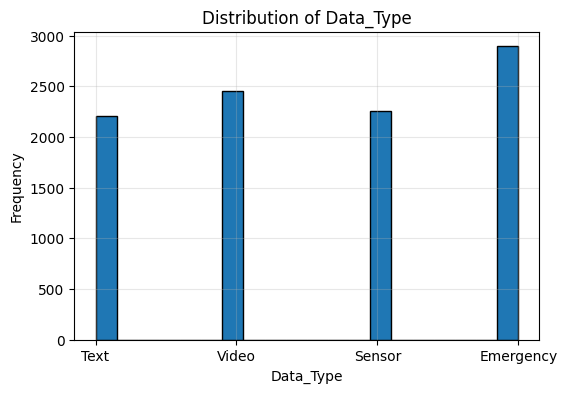

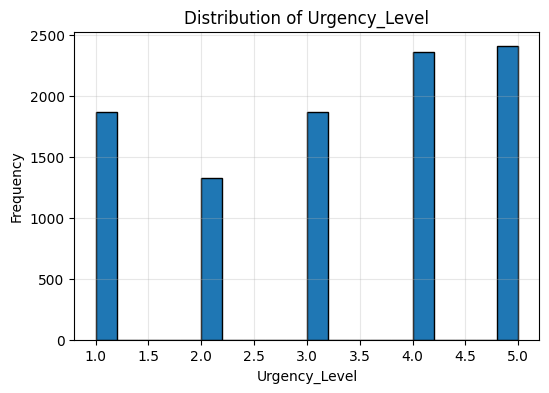

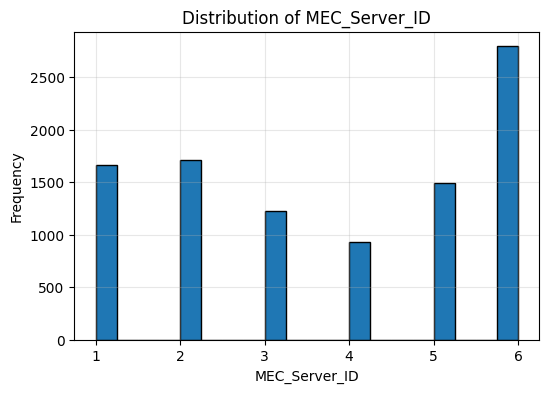

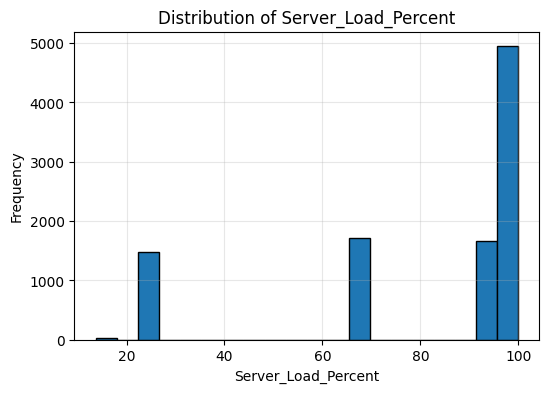

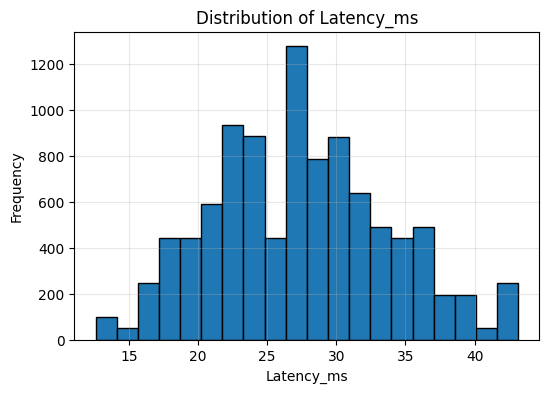

In [24]:
for col in network_features:
    plt.figure(figsize=(6,4))
    plt.hist(data[col], bins=20, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)
    plt.show()

In [25]:
sorted(data["MEC_Server_ID"].unique())

[np.float64(1.0),
 np.float64(2.0),
 np.float64(3.0),
 np.float64(4.0),
 np.float64(5.0),
 np.float64(6.0)]

In [26]:
data[
    ["Server_Load_Percent",

     "Latency_ms"]
].corr()

,Server_Load_Percent,Latency_ms
Server_Load_Percent,1.000000,-0.020747
Latency_ms,-0.020747,1.000000


In [27]:
print(data["Road_Type"].value_counts())

Road_Type
Highway    3830
Urban      2996
Rural      2993
Name: count, dtype: int64


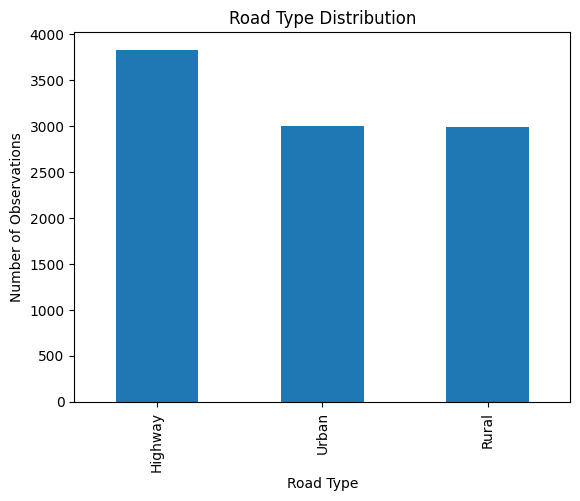

In [28]:
data["Road_Type"].value_counts().plot(kind="bar")

plt.title("Road Type Distribution")
plt.xlabel("Road Type")
plt.ylabel("Number of Observations")

plt.show()

In [29]:

corr = data.corr(numeric_only=True)

print(corr["Traffic_Density"].sort_values(ascending=False))


Traffic_Density        1.000000
Latency_ms             0.509337
Speed_kmh              0.075350
Vehicle_ID             0.073731
Urgency_Level          0.010547
Time Step             -0.000647
MEC_Server_ID         -0.009520
Longitude             -0.045537
Latitude              -0.066239
Server_Load_Percent   -0.154981
Name: Traffic_Density, dtype: float64


In [30]:
print(data["Data_Type"].value_counts())

Data_Type
Emergency    2894
Video        2454
Sensor       2259
Text         2212
Name: count, dtype: int64


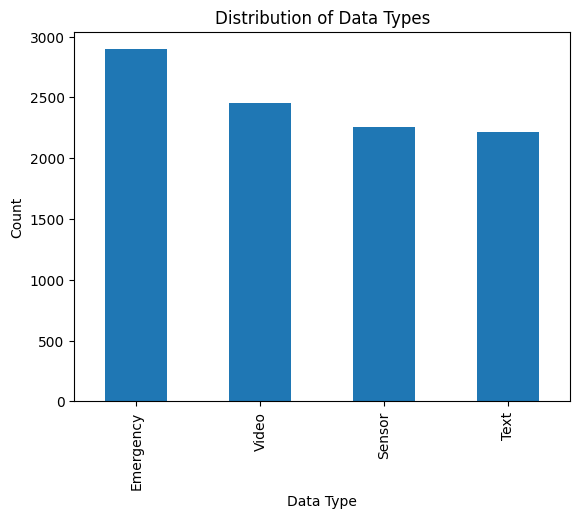

In [31]:
data["Data_Type"].value_counts().plot(kind="bar")

plt.title("Distribution of Data Types")
plt.xlabel("Data Type")
plt.ylabel("Count")

plt.show()

In [32]:
print(data["Urgency_Level"].describe())

count    9819.000000
mean        3.214482
std         1.438715
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Urgency_Level, dtype: float64


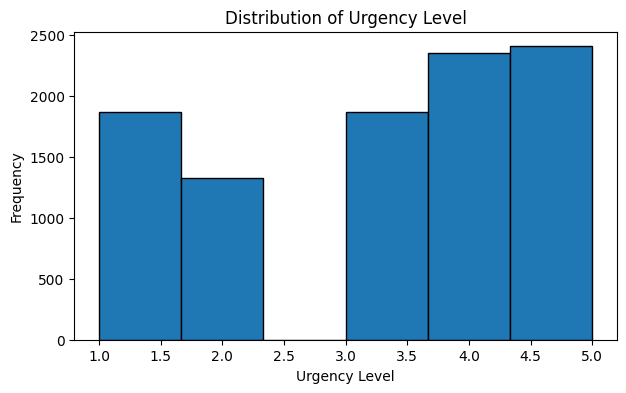

In [33]:
plt.figure(figsize=(7,4))

plt.hist(data["Urgency_Level"], bins=6, edgecolor="black")

plt.xlabel("Urgency Level")
plt.ylabel("Frequency")
plt.title("Distribution of Urgency Level")

plt.show()

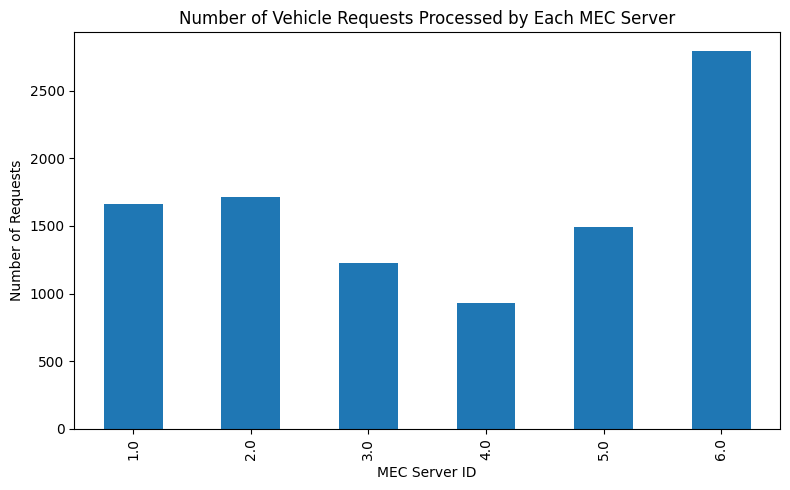

In [34]:
import matplotlib.pyplot as plt

server_counts = data['MEC_Server_ID'].value_counts().sort_index()

plt.figure(figsize=(8,5))
server_counts.plot(kind='bar')

plt.title('Number of Vehicle Requests Processed by Each MEC Server')
plt.xlabel('MEC Server ID')
plt.ylabel('Number of Requests')

plt.tight_layout()
plt.show()

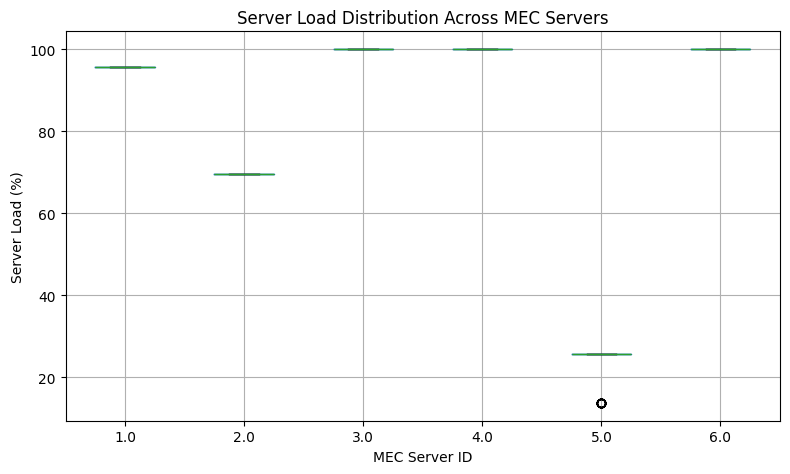

In [35]:

data.boxplot(column='Server_Load_Percent', by='MEC_Server_ID', figsize=(8,5))

plt.title('Server Load Distribution Across MEC Servers')
plt.suptitle('')
plt.xlabel('MEC Server ID')
plt.ylabel('Server Load (%)')

plt.tight_layout()
plt.show()

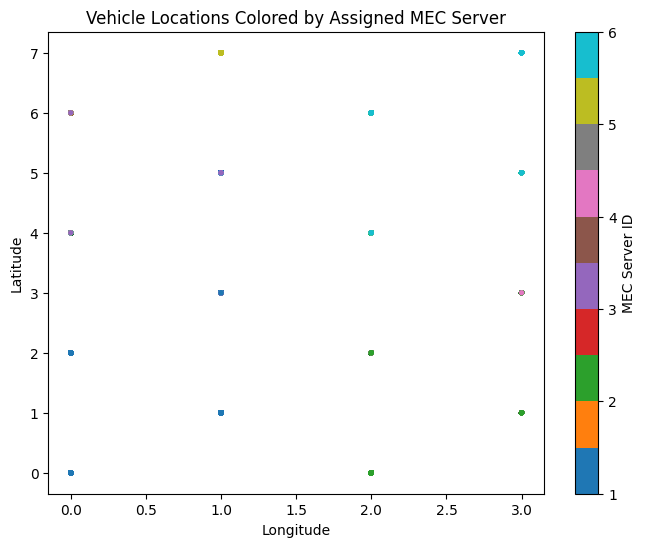

In [36]:


plt.figure(figsize=(8,6))

plt.scatter(
    data['Longitude'],
    data['Latitude'],
    c=data['MEC_Server_ID'],
    cmap='tab10',
    s=8
)

plt.colorbar(label='MEC Server ID')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Vehicle Locations Colored by Assigned MEC Server')

plt.show()

In [37]:
data['MEC_Server_ID'].value_counts().sort_index()

,count
MEC_Server_ID,
1.0,1666
2.0,1715
3.0,1225
4.0,931
5.0,1489
6.0,2793


In [38]:
# Numerical correlations
data.corr(numeric_only=True)['MEC_Server_ID'].sort_values(ascending=False)

,MEC_Server_ID
MEC_Server_ID,1.000000
Latitude,0.750032
Longitude,0.250916
Latency_ms,0.055171
Vehicle_ID,0.028507
Time Step,-0.002281
Traffic_Density,-0.009520
Urgency_Level,-0.039899
Server_Load_Percent,-0.058082
Speed_kmh,-0.096273


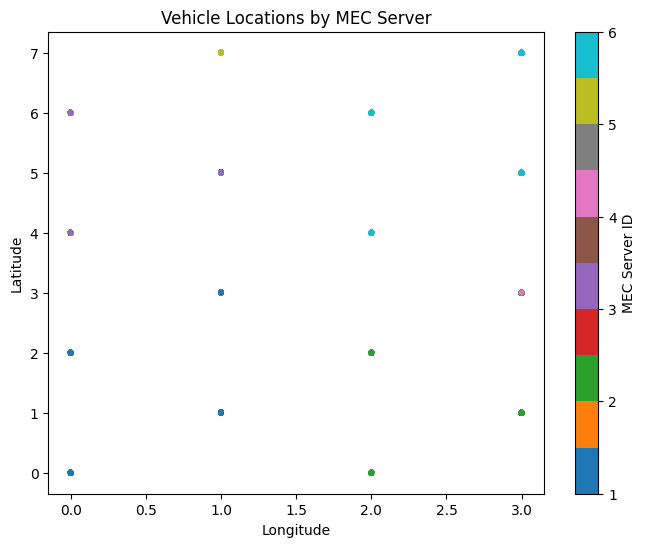

In [39]:


plt.figure(figsize=(8,6))
plt.scatter(data['Longitude'], data['Latitude'],
            c=data['MEC_Server_ID'],
            cmap='tab10',
            s=10)

plt.colorbar(label='MEC Server ID')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Vehicle Locations by MEC Server')
plt.show()

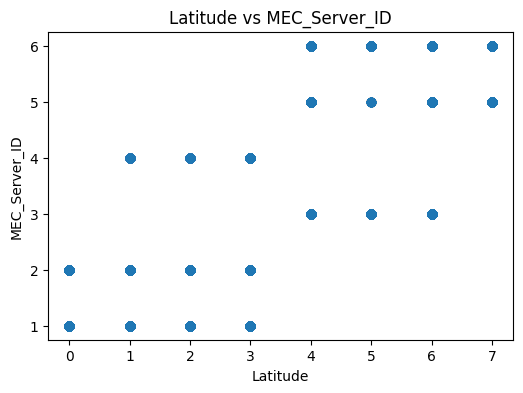

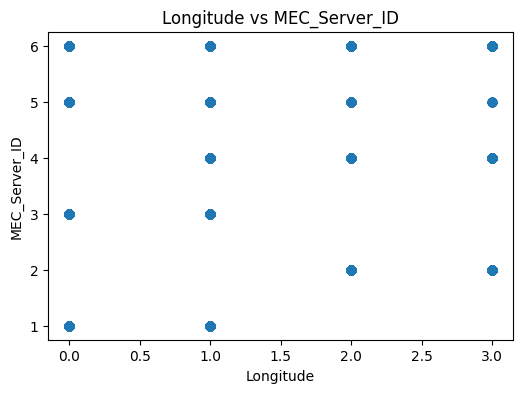

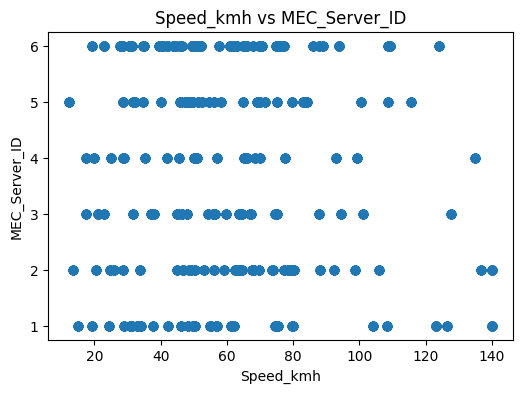

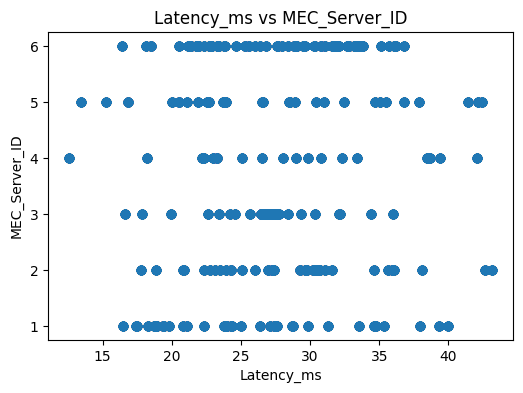

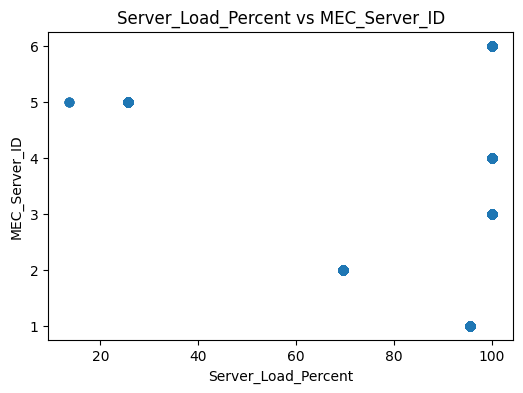

In [40]:
import matplotlib.pyplot as plt

features = [
    'Latitude', 'Longitude', 'Speed_kmh',
    'Latency_ms',
    'Server_Load_Percent'
]

for feature in features:
    plt.figure(figsize=(6,4))
    plt.scatter(data[feature], data['MEC_Server_ID'], alpha=0.3)
    plt.xlabel(feature)
    plt.ylabel('MEC_Server_ID')
    plt.title(f'{feature} vs MEC_Server_ID')
    plt.show()

In [41]:
import pandas as pd
from scipy import stats

df = pd.read_csv("mec_training_dataset_v2.csv")

# 1. Group-by means — do servers actually differ?
print(df.groupby('MEC_Server_ID')['Server_Load_Percent'].agg(['mean', 'std', 'count']))
print(df.groupby('MEC_Server_ID')['Latency_ms'].agg(['mean', 'std', 'count']))

# 2. ANOVA — is the difference statistically significant?
def anova_by_group(df, group_col, value_col):
    groups = [g[value_col].dropna().values for _, g in df.groupby(group_col)]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"{value_col} ~ {group_col}: F={f_stat:.3f}, p={p_val:.5f}")
    return f_stat, p_val

anova_by_group(df, 'MEC_Server_ID', 'Server_Load_Percent')
anova_by_group(df, 'MEC_Server_ID', 'Latency_ms')

# 3. Kruskal-Wallis (non-parametric backup, in case data isn't normal)
def kruskal_by_group(df, group_col, value_col):
    groups = [g[value_col].dropna().values for _, g in df.groupby(group_col)]
    h_stat, p_val = stats.kruskal(*groups)
    print(f"{value_col} ~ {group_col} (Kruskal): H={h_stat:.3f}, p={p_val:.5f}")
    return h_stat, p_val

kruskal_by_group(df, 'MEC_Server_ID', 'Server_Load_Percent')
kruskal_by_group(df, 'MEC_Server_ID', 'Latency_ms')

# 4. Eta-squared (effect size — how much variance MEC_Server_ID explains)
def eta_squared(df, group_col, value_col):
    grand_mean = df[value_col].mean()
    ss_between = sum(len(g) * (g[value_col].mean() - grand_mean)**2
                      for _, g in df.groupby(group_col))
    ss_total = sum((df[value_col] - grand_mean)**2)
    return ss_between / ss_total

print("Eta² (Load):", eta_squared(df, 'MEC_Server_ID', 'Server_Load_Percent'))
print("Eta² (Latency):", eta_squared(df, 'MEC_Server_ID', 'Latency_ms'))

                     mean       std  count
MEC_Server_ID                             
1.0             95.500000  0.000000   1666
2.0             69.500000  0.000000   1715
3.0            100.000000  0.000000   1225
4.0            100.000000  0.000000    931
5.0             25.516877  1.347311   1489
6.0            100.000000  0.000000   2793
                    mean       std  count
MEC_Server_ID                            
1.0            25.903235  6.704661   1666
2.0            28.607429  6.046294   1715
3.0            26.704800  4.459798   1225
4.0            28.332105  7.577438    931
5.0            27.349563  8.034838   1489
6.0            27.800877  5.328802   2793
Server_Load_Percent ~ MEC_Server_ID: F=5029344.553, p=0.00000
Latency_ms ~ MEC_Server_ID: F=40.422, p=0.00000
Server_Load_Percent ~ MEC_Server_ID (Kruskal): H=9816.493, p=0.00000
Latency_ms ~ MEC_Server_ID (Kruskal): H=218.934, p=0.00000
Eta² (Load): 0.9996099224435598
Eta² (Latency): 0.020180486133933726


In [42]:


# 1. How many unique lat/long pairs exist?
unique_coords = df[['Latitude', 'Longitude']].drop_duplicates()
print("Unique lat/long pairs:", len(unique_coords))
print("Total rows:", len(df))

# 2. Compare unique coordinate count to unique MEC_Server_ID count and Vehicle_ID count
print("Unique MEC_Server_ID:", df['MEC_Server_ID'].nunique())
print("Unique Vehicle_ID:", df['Vehicle_ID'].nunique() if 'Vehicle_ID' in df else "N/A")

# 3. Check: does each MEC_Server_ID map to a FIXED lat/long (one-to-one)?
server_coord_check = df.groupby('MEC_Server_ID')[['Latitude','Longitude']].nunique()
print(server_coord_check)

# 4. Check: does each Vehicle_ID map to MANY different lat/long (moving)?
if 'Vehicle_ID' in df:
    vehicle_coord_check = df.groupby('Vehicle_ID')[['Latitude','Longitude']].nunique()
    print(vehicle_coord_check.describe())

Unique lat/long pairs: 16
Total rows: 9819
Unique MEC_Server_ID: 6
Unique Vehicle_ID: 200
               Latitude  Longitude
MEC_Server_ID                     
1.0                   4          2
2.0                   4          2
3.0                   3          2
4.0                   3          3
5.0                   4          4
6.0                   4          4
       Latitude  Longitude
count     200.0      200.0
mean        1.0        1.0
std         0.0        0.0
min         1.0        1.0
25%         1.0        1.0
50%         1.0        1.0
75%         1.0        1.0
max         1.0        1.0


In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("mec_training_dataset_v2.csv")

features = ['Traffic_Density', 'Speed_kmh', 'Weather', 'Road_Type',
            'Acceleration_mps2', 'Urgency_Level']  # adjust to your actual column names
target = 'Server_Load_Percent'

# Keep only columns that exist
features = [f for f in features if f in df.columns]
data = df[features + [target]].dropna().copy()

# Encode categorical columns
for col in data.select_dtypes(include='object').columns:
    if col != target:
        data[col] = LabelEncoder().fit_transform(data[col])

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print("R²:", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))

# Feature importance
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

R²: 0.9993394903103023
MAE: 0.05494548061350036
Traffic_Density    0.345888
Speed_kmh          0.322066
Urgency_Level      0.235497
Weather            0.064986
Road_Type          0.031563
dtype: float64


In [44]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
df = pd.read_csv("mec_training_dataset_v2.csv")

features = ['Traffic_Density', 'Speed_kmh', 'Bandwidth_Mbps',
            'Signal_Strength_dBm', 'Weather', 'Road_Type',
            'Acceleration_mps2', 'Urgency_Level']
features = [f for f in features if f in df.columns]

# --- 1. Sanity check: nulls, dtypes, encoding ---
print("Nulls per column:\n", df[features].isnull().sum())
print("\nDtypes:\n", df[features].dtypes)
for col in df[features].select_dtypes(include='object').columns:
    print(f"\n{col} unique values:", df[col].unique())

targets_to_test = ['Server_Load_Percent', 'Latency_ms']

for target in targets_to_test:
    data = df[features + [target]].dropna().copy()
    for col in data.select_dtypes(include='object').columns:
        if col != target:
            data[col] = LabelEncoder().fit_transform(data[col])

    X = data[features]
    y = data[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)

    # 5-fold cross-validation for robustness
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

    print(f"\n--- Target: {target} ---")
    print(f"R²: {r2:.4f} | MAE: {mae:.4f}")
    print(f"5-fold CV R² scores: {np.round(cv_scores, 4)} | mean: {cv_scores.mean():.4f}")

Nulls per column:
 Traffic_Density    0
Speed_kmh          0
Weather            0
Road_Type          0
Urgency_Level      0
dtype: int64

Dtypes:
 Traffic_Density    float64
Speed_kmh          float64
Weather             object
Road_Type           object
Urgency_Level      float64
dtype: object

Weather unique values: ['Rain' 'Clear' 'Fog']

Road_Type unique values: ['Urban' 'Highway' 'Rural']

--- Target: Server_Load_Percent ---
R²: 0.9993 | MAE: 0.0549
5-fold CV R² scores: [0.9981 1.     1.     1.     1.    ] | mean: 0.9996

--- Target: Latency_ms ---
R²: 1.0000 | MAE: 0.0000
5-fold CV R² scores: [1. 1. 1. 1. 1.] | mean: 1.0000


In [46]:



print(pd.crosstab(df["MEC_Server_ID"], df["Weather"], normalize='index').round(3))

Weather        Clear    Fog   Rain
MEC_Server_ID                     
1.0            0.529  0.176  0.294
2.0            0.400  0.314  0.286
3.0            0.360  0.400  0.240
4.0            0.421  0.263  0.316
5.0            0.334  0.399  0.267
6.0            0.193  0.386  0.421
